In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data_rocket = pd.read_csv ("base_dados_lancamento_foguete.csv")

In [ ]:
data_rocket.head()


,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,pressao_tanque,modulo_navegacao,modulo_propulsao,modulo_comunicacao,status_lancamento
0,27.483571,29.261775,1,88.652936,99.072373,OK,OK,FALHA,DECOLAGEM ABORTADA
1,24.308678,39.094166,1,62.883373,97.743531,OK,OK,OK,DECOLAGEM ABORTADA
2,28.238443,6.014324,1,62.850269,100.957524,OK,OK,OK,DECOLAGEM ABORTADA
3,32.615149,25.629692,1,60.484339,104.021351,FALHA,OK,OK,DECOLAGEM ABORTADA
4,23.829233,13.493574,0,98.260056,94.374483,OK,OK,OK,DECOLAGEM ABORTADA


In [4]:
def verificar_lancamento(row):

    if row["integridade_estrutural"] == 0:
        resultado = "DECOLAGEM ABORTADA"

    elif row["pressao_tanque"] < 95 or row["pressao_tanque"] > 105:
        resultado = "DECOLAGEM ABORTADA"

    elif row["nivel_energia"] < 80:
        resultado = "DECOLAGEM ABORTADA"

    elif row["temperatura_interna"] < 15 or row["temperatura_interna"] > 35:
        resultado = "DECOLAGEM ABORTADA"

    elif row["modulo_navegacao"] == "FALHA":
        resultado = "DECOLAGEM ABORTADA"

    elif row["modulo_propulsao"] == "FALHA":
        resultado = "DECOLAGEM ABORTADA"

    elif row["modulo_comunicacao"] == "FALHA":
        resultado = "DECOLAGEM ABORTADA"

    elif row["temperatura_externa"] > 45:
        resultado = "PRONTO PARA DECOLAR COM ALERTA"

    else:
        resultado = "PRONTO PARA DECOLAR"

    return resultado

In [ ]:
data_rocket["resultado"] = data_rocket.apply(verificar_lancamento, axis = 1)

In [6]:
data_rocket.head ()

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,pressao_tanque,modulo_navegacao,modulo_propulsao,modulo_comunicacao,status_lancamento,resultado
0,27.483571,29.261775,1,88.652936,99.072373,OK,OK,FALHA,DECOLAGEM ABORTADA,DECOLAGEM ABORTADA
1,24.308678,39.094166,1,62.883373,97.743531,OK,OK,OK,DECOLAGEM ABORTADA,DECOLAGEM ABORTADA
2,28.238443,6.014324,1,62.850269,100.957524,OK,OK,OK,DECOLAGEM ABORTADA,DECOLAGEM ABORTADA
3,32.615149,25.629692,1,60.484339,104.021351,FALHA,OK,OK,DECOLAGEM ABORTADA,DECOLAGEM ABORTADA
4,23.829233,13.493574,0,98.260056,94.374483,OK,OK,OK,DECOLAGEM ABORTADA,DECOLAGEM ABORTADA


In [7]:
data_rocket ['resultado'].value_counts()

resultado
DECOLAGEM ABORTADA     305
PRONTO PARA DECOLAR    195
Name: count, dtype: int64

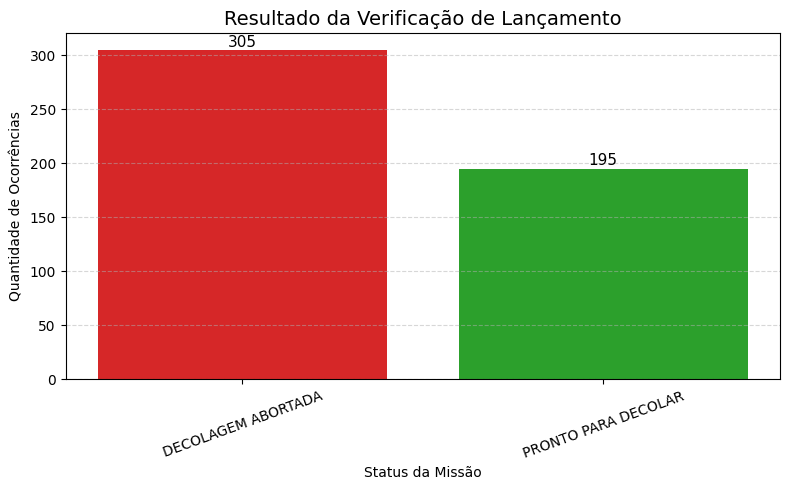

In [ ]:


counts = data_rocket["resultado"].value_counts()

plt.figure(figsize=(8,5))

bars = plt.bar(
    counts.index,
    counts.values,
    color=["#d62728", "#2ca02c"]  # vermelho abortado, verde pronto
)

plt.title("Resultado da Verificação de Lançamento", fontsize=14)
plt.xlabel("Status da Missão")
plt.ylabel("Quantidade de Ocorrências")

plt.xticks(rotation=20)

# adicionar números em cima das barras
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 3,
        int(height),
        ha="center",
        fontsize=11
    )

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Filtrar apenas os lançamentos abortados 

In [ ]:
abortos = data_rocket[data_rocket["resultado"] == "DECOLAGEM ABORTADA"]


contar quantas vezes cada sensor falhou

In [ ]:
pressao_falha = abortos[(abortos["pressao_tanque"] < 95) | (abortos["pressao_tanque"] > 105)].shape[0]
energia_falha = abortos[abortos["nivel_energia"] < 80].shape[0]
temp_falha = abortos[(abortos["temperatura_interna"] < 15) | (abortos["temperatura_interna"] > 35)].shape[0]

modulo_falha = abortos[
    (abortos["modulo_navegacao"] == "FALHA") |
    (abortos["modulo_propulsao"] == "FALHA") |
    (abortos["modulo_comunicacao"] == "FALHA")
].shape[0]

In [29]:
causas = {
    "Pressão": pressao_falha,
    "Energia": energia_falha,
    "Temperatura": temp_falha,
    "Módulos": modulo_falha
}

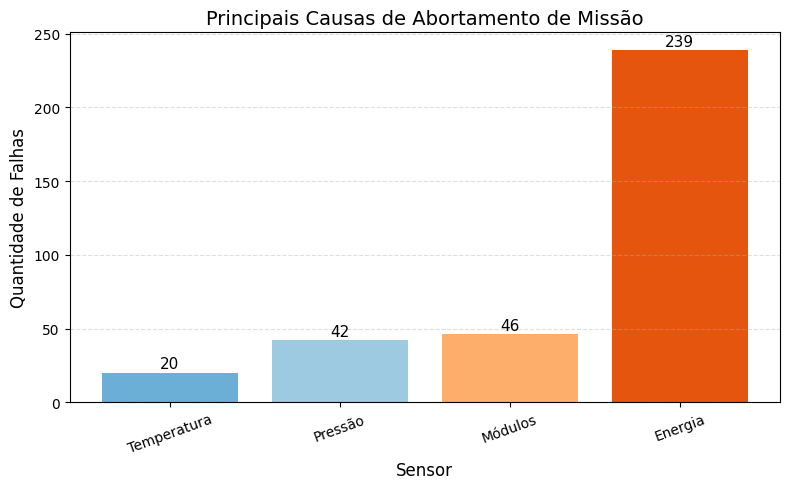

In [ ]:


# transformar o dicionário em série para ordenar
causas_series = pd.Series(causas).sort_values()

plt.figure(figsize=(8,5))

bars = plt.bar(
    causas_series.index,
    causas_series.values,
    color=["#6baed6","#9ecae1","#fdae6b","#e6550d"]
)

plt.title("Principais Causas de Abortamento de Missão", fontsize=14)
plt.xlabel("Sensor", fontsize=12)
plt.ylabel("Quantidade de Falhas", fontsize=12)

plt.xticks(rotation=20)

# adicionar números em cima das barras
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 3,
        int(height),
        ha="center",
        fontsize=11
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()